In [20]:
!pip install pennylane

In [21]:
import pennylane as qml
import matplotlib.pyplot as plt
from pennylane import numpy as np
from pennylane.optimize import NesterovMomentumOptimizer
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [22]:
seed = 100
np.random.seed(seed)

### Parameters

In [23]:
num_qubits = 2
num_layers = 4
num_params = num_layers * num_qubits * 3

num_epochs = 30
batch_size = 20
learning_rate = 3e-2

### Circuit

In [24]:
dev = qml.device('default.qubit', wires = num_qubits)

@qml.qnode(dev)
def classifier_circuit(weights, x_input, num_qubits, num_layers):
    for i in range(num_layers):
        for j in range(num_qubits):
            # encode features
            qml.RX(x_input[i][j][0], wires = j)
            qml.RY(x_input[i][j][1], wires = j)
            qml.RZ(x_input[i][j][2], wires = j)

            # trained parameters
            qml.RX(weights[i][j][0], wires = j)
            qml.RY(weights[i][j][1], wires = j)
            qml.RZ(weights[i][j][2], wires = j)

            if j < num_qubits - 1:
                qml.CNOT(wires=[j, j+1])

    return qml.expval(qml.PauliZ(0))

def prediction(weights, bias, x_input, num_qubits, num_layers):
    predictions = [classifier_circuit(weights, x_input[i], num_qubits, num_layers) + bias for i in range(len(x_input))]
    return predictions

def loss(weights, bias, x_input, y, num_qubits, num_layers):
    preds = prediction(weights, bias, x_input, num_qubits, num_layers)
    mse = np.mean((np.array(preds) - y)**2)
    return mse

def acc(labels, predictions):
    predictions = np.sign(predictions)
    acc = sum(abs(l-p) < 1e-2 for l,p in zip(labels, predictions))/len(labels)
    return acc

### Pre-process Data

In [25]:
def data_produce(features, num_layers, num_qubits, num_repeat):
    B, L = features.shape

    features = np.repeat(features, num_repeat, axis=1)
    features = features.reshape(B, num_layers, num_qubits, 3)

    # Normalize the features to [-π, π] range for quantum gates
    features = np.pi * features / np.max(np.abs(features))

    return features

In [26]:
iris = datasets.load_iris()
features = iris.data[:100,:].astype(np.float32)
labels = iris.target[:100].astype(int)

scaler = StandardScaler()
features = scaler.fit_transform(features)

num_repeat = num_params / features.shape[1] # repeat features for several times and encode this in the circuit
features = data_produce(features, num_layers, num_qubits, num_repeat)

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42, shuffle=False)
num_train = len(X_train)

### Training

In [27]:
weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3, requires_grad = True)
bias_init = np.array(0.0, requires_grad=True)

opt = NesterovMomentumOptimizer(stepsize=learning_rate)

weights = weights_init
bias = bias_init

train_loss = []
test_acc = []
weights_check = [0,0]
for epoch in range(num_epochs):
    prediction_test = prediction(weights, bias, X_test, num_qubits, num_layers)
    current_test_acc = acc(y_test, prediction_test)
    test_acc.append(current_test_acc)

    weights_check[0] = weights
    batch_index = np.random.randint(0, num_train, (batch_size,))
    X_train_batch = X_train[batch_index]
    Y_train_batch = y_train[batch_index]
    weights, bias, _, _, _, _ = opt.step(loss, weights, bias, X_train_batch, Y_train_batch, num_qubits, num_layers)

    current_train_loss = loss(weights, bias, X_train_batch, Y_train_batch, num_qubits, num_layers)
    train_loss.append(current_train_loss)

    weights_check[1] = weights

    print(f"Test: Iterations {epoch}, Accuracy {current_test_acc:.4f} | Train: Iterations {epoch+1}, Loss {current_train_loss:.4f}")
    # print(epoch+1, qml.math.linalg.norm(weights_check[0]-weights_check[1])) #check gradients

Test: Iterations 0, Accuracy 0.2500 | Train: Iterations 1, Loss 0.9010
Test: Iterations 1, Accuracy 0.3000 | Train: Iterations 2, Loss 1.1094
Test: Iterations 2, Accuracy 0.3500 | Train: Iterations 3, Loss 0.6279
Test: Iterations 3, Accuracy 0.4500 | Train: Iterations 4, Loss 0.4589
Test: Iterations 4, Accuracy 0.5500 | Train: Iterations 5, Loss 0.3699
Test: Iterations 5, Accuracy 0.7000 | Train: Iterations 6, Loss 0.4344
Test: Iterations 6, Accuracy 0.7500 | Train: Iterations 7, Loss 0.3597
Test: Iterations 7, Accuracy 0.8000 | Train: Iterations 8, Loss 0.3421
Test: Iterations 8, Accuracy 0.8500 | Train: Iterations 9, Loss 0.2296
Test: Iterations 9, Accuracy 0.8500 | Train: Iterations 10, Loss 0.2542
Test: Iterations 10, Accuracy 0.8500 | Train: Iterations 11, Loss 0.2583
Test: Iterations 11, Accuracy 1.0000 | Train: Iterations 12, Loss 0.2177
Test: Iterations 12, Accuracy 1.0000 | Train: Iterations 13, Loss 0.2384
Test: Iterations 13, Accuracy 1.0000 | Train: Iterations 14, Loss 0.17

### Plot

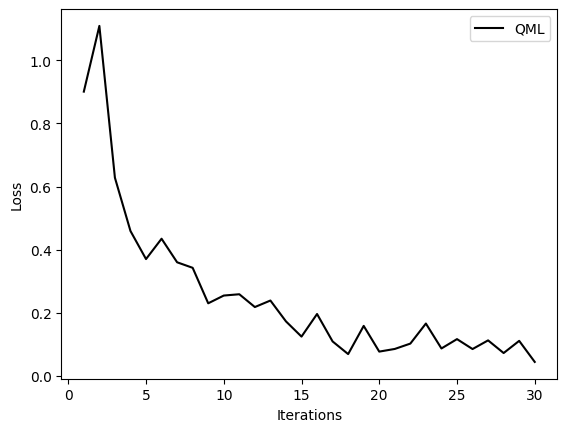

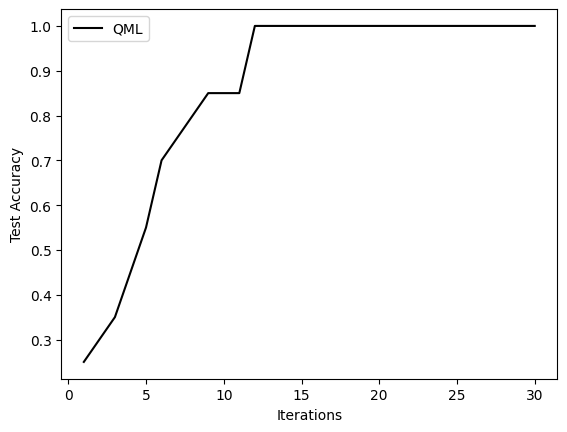

In [28]:
plt.figure()
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.plot(range(1, len(test_acc)+1), train_loss, color = 'black', label = 'QML')
plt.legend()
plt.show()

plt.figure()
plt.xlabel("Iterations")
plt.ylabel("Test Accuracy")
plt.plot(range(1, len(test_acc)+1), test_acc, color = 'black', label = 'QML')
plt.legend()
plt.show()